<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)



1) LOAD DATA

In [4]:
df = pd.read_csv("/content/Crop_training_data_FULL.csv")

df["suitability_class"] = df["suitability_class"].map({
    "Unsuitable": 0,
    "Suitable": 1
})

X = df.drop(columns=["suitability_class", "suitability"])
y = df["suitability_class"]

X = pd.get_dummies(X, drop_first=True)


2) TRAIN / TEST SPLIT

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

3) MODEL

In [6]:
gb = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.05,
    max_iter=300,
    random_state=42
)

gb.fit(X_train, y_train)


HistGradientBoostingClassifier(learning_rate=0.05, max_depth=8, max_iter=300,
                               random_state=42)

4) EVALUATION

In [7]:
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== GRADIENT BOOSTING RESULTS ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== GRADIENT BOOSTING RESULTS ===
Accuracy : 0.7976
ROC AUC  : 0.9004
AUPRC    : 0.8733

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       244
           1       0.79      0.70      0.74       176

    accuracy                           0.80       420
   macro avg       0.80      0.78      0.79       420
weighted avg       0.80      0.80      0.80       420



 5) ROC CURVE

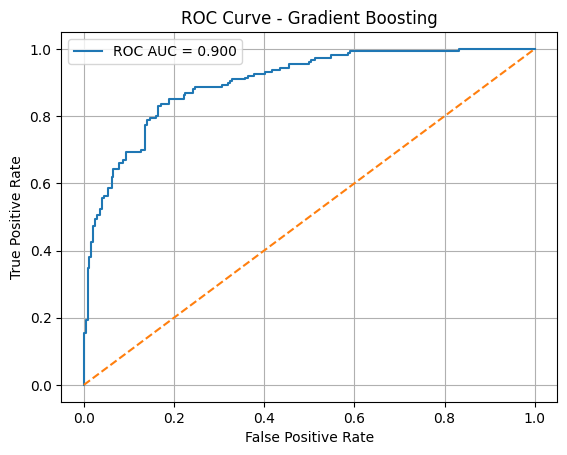

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.grid()
plt.show()

6) PRECISION-RECALL CURVE


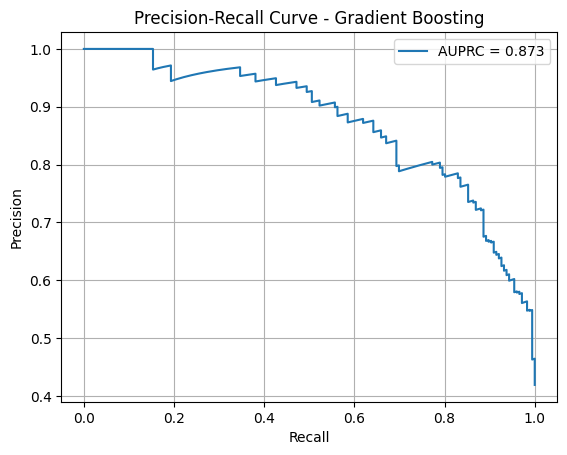

In [9]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.legend()
plt.grid()
plt.show()